In [90]:
%pip install matplotlib numpy
%config IPCompleter.greedy=True

Note: you may need to restart the kernel to use updated packages.


In [91]:
import numpy as np 
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = [12, 7.42]

In [92]:
L = 1
alpha = 0.01
Nx = 50
dx = L/Nx
dt_max = 0.02
r = 0.4
dt = r * dt_max
T0 = 1

In [93]:
def distribuzione_sin(T0: float, x: float, t: float, alpha: float, L: float) -> float:
    T_in = T0 * np.sin(np.pi * x / L)
    return T0 * np.exp(-alpha * np.pi**2 * t / L**2) * np.sin(np.pi * x / L)

xs = np.linspace(0, L, Nx+1)

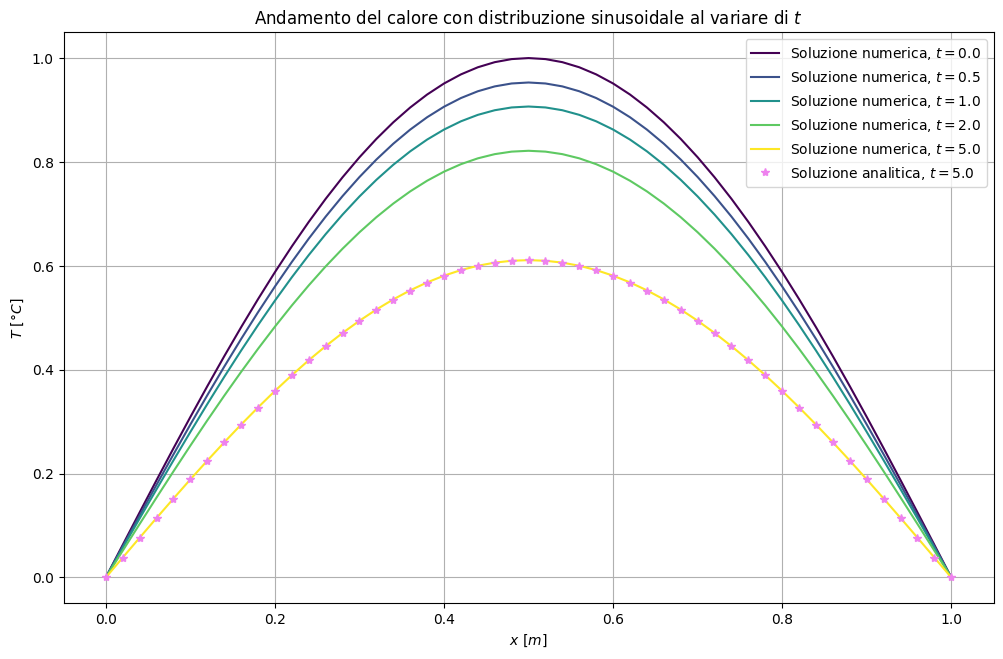

In [180]:
def ftcs(T0: float, Tl: float, Tr: float, x: list[float], t: float, dt: float, L: float, alpha: float, dx: float) -> list[float]:
    r = alpha * dt / (dx**2)
    steps = t / dt
    Ts = np.zeros((int(steps), len(x)))
    Ts[0,:] = T0 * np.sin(np.pi * x / L)
    Ts[:, 0], Ts[:, -1] = Tl, Tr
    
    for i in range(int(steps)-1):
        for j in range(1, len(xs)-1):
            Ts[i+1][j] = Ts[i][j] + r * (Ts[i][j+1] - 2*Ts[i][j] + Ts[i][j-1])
    return Ts

Ts = ftcs(T0=1, Tl=0, Tr=0, x=xs, t=5, dt=dt, L=L, alpha=alpha, dx=dx)
distr_sin = distribuzione_sin(T0=T0, x=xs, t=5, alpha=alpha, L=L)
cmap = plt.cm.viridis
times = [0.0, 0.5, 1.0, 2.0, 5.0]

for idx, t in enumerate(times):
    riga = int(t/dt)
    colore = cmap(idx / (len(times) - 1))
    if riga == 0:
        plt.plot(xs, Ts[riga, :], label=rf"Soluzione numerica, $t={t}$", color=colore)
    else:
        plt.plot(xs, Ts[riga-1, :], label=rf"Soluzione numerica, $t={t}$", color=colore)

plt.plot(xs, distr_sin, "*", label=r"Soluzione analitica, $t=5.0$", color="violet")
plt.xlabel(r"$x\ [m]$")
plt.ylabel(r"$T\ [°C]$")
plt.title(r"Andamento del calore con distribuzione sinusoidale al variare di $t$")
plt.grid()
plt.legend()
plt.show()

In [95]:
err_max_fin = np.max(np.abs(Ts[-1, :] - distr_sin))
print(err_max_fin)

0.0004624165953999171


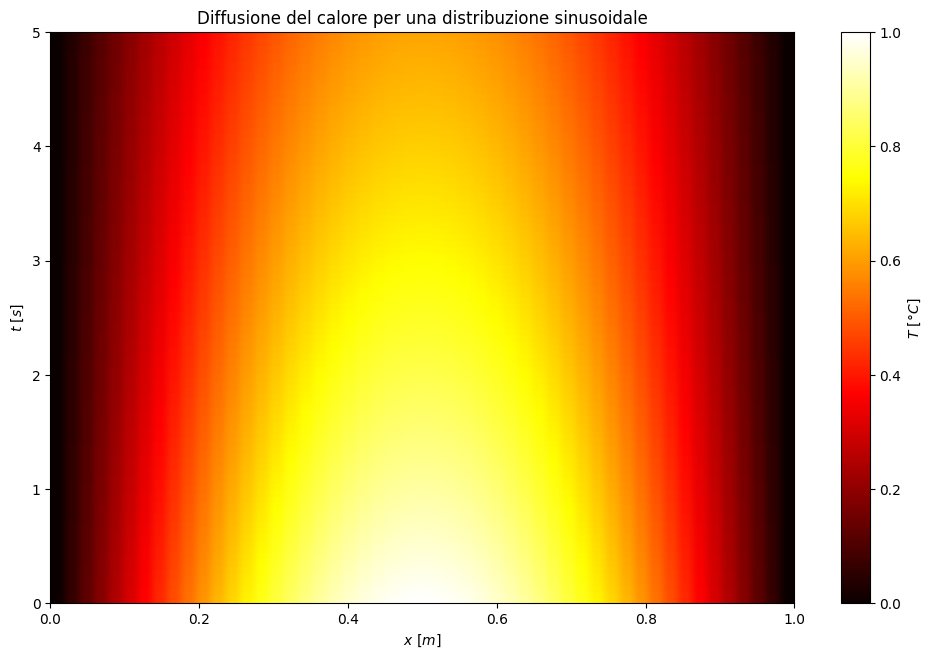

In [172]:
extent = [0, L, 0, len(Ts)*dt]
plt.imshow(Ts, extent=extent, aspect="auto", origin="lower", cmap="hot")
cbar = plt.colorbar()
cbar.set_label(r"$T\ [°C]$")
plt.xlabel(r"$x\ [m]$")
plt.ylabel(r"$t\ [s]$")
plt.title("Diffusione del calore per una distribuzione sinusoidale")
plt.show()

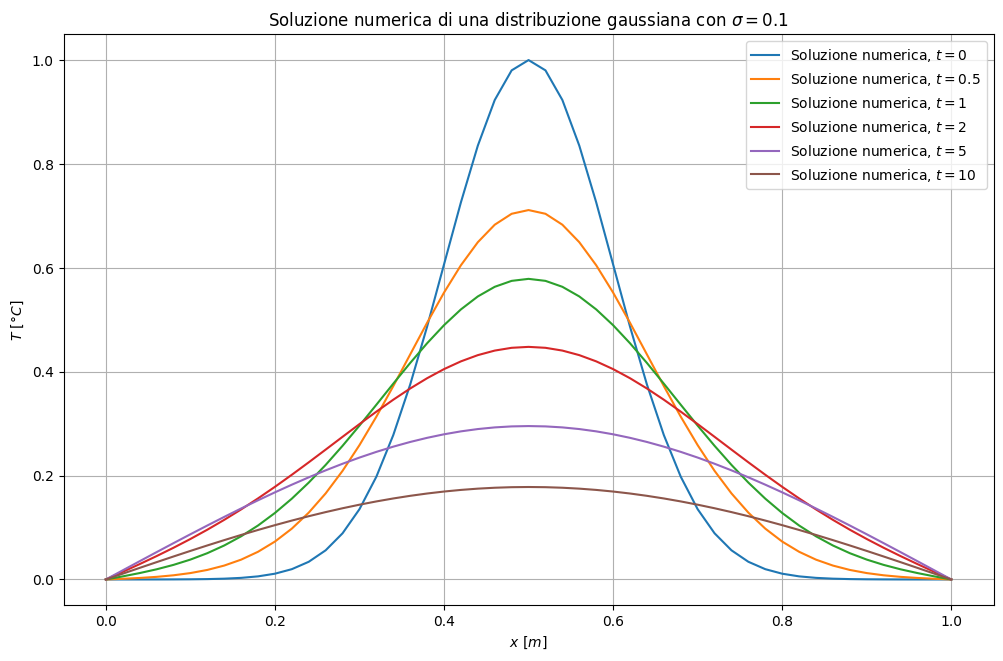

In [187]:
def ftcs1(T0: float, Tl: float, Tr: float, x: list[float], t: float, dt: float, L: float, alpha: float, dx: float) -> list[float]:
    r = alpha * dt / (dx**2)
    sigma = 0.1 * L
    steps = t / dt
    Ts = np.ones((int(steps), len(x)))
    Ts[0] = T0 * np.exp(-(x - L/2)**2 / (2 * sigma**2))
    
    for i in range(int(steps)-1):
        for j in range(1, len(xs)-1):
            Ts[i+1][j] = Ts[i][j] + r * (Ts[i][j+1] - 2*Ts[i][j] + Ts[i][j-1])
        Ts[i+1][0], Ts[i+1][-1] = Tl, Tr
    return Ts

Ts1 = ftcs1(T0=1, Tl=0, Tr=0, x=xs, t=10, dt=dt, L=L, alpha=alpha, dx=dx)

for i in [0, 0.5, 1, 2, 5, 10]:
    riga = int(i/dt)
    if riga == 0:
        plt.plot(xs, Ts1[riga, :], label=rf"Soluzione numerica, $t={i}$")
    else:
        plt.plot(xs, Ts1[riga-1, :], label=rf"Soluzione numerica, $t={i}$")

plt.grid()
plt.legend()
plt.xlabel(r"$x\ [m]$")
plt.ylabel(r"$T\ [°C]$")
plt.title(r"Soluzione numerica di una distribuzione gaussiana con $\sigma=0.1$")
plt.show()

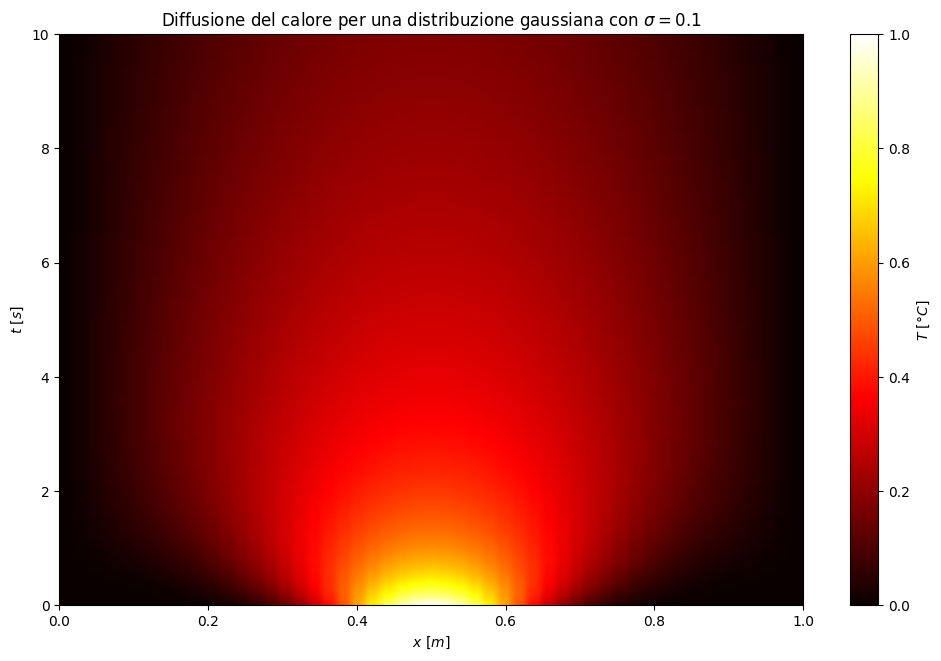

In [171]:
extent1 = [0, L, 0, len(Ts1)*dt]
plt.imshow(Ts1, extent=extent1, aspect="auto", origin="lower", cmap="hot")
cbar = plt.colorbar()
cbar.set_label(r"$T\ [°C]$")
plt.xlabel(r"$x\ [m]$")
plt.ylabel(r"$t\ [s]$")
plt.title(r"Diffusione del calore per una distribuzione gaussiana con $\sigma=0.1$")
plt.show()

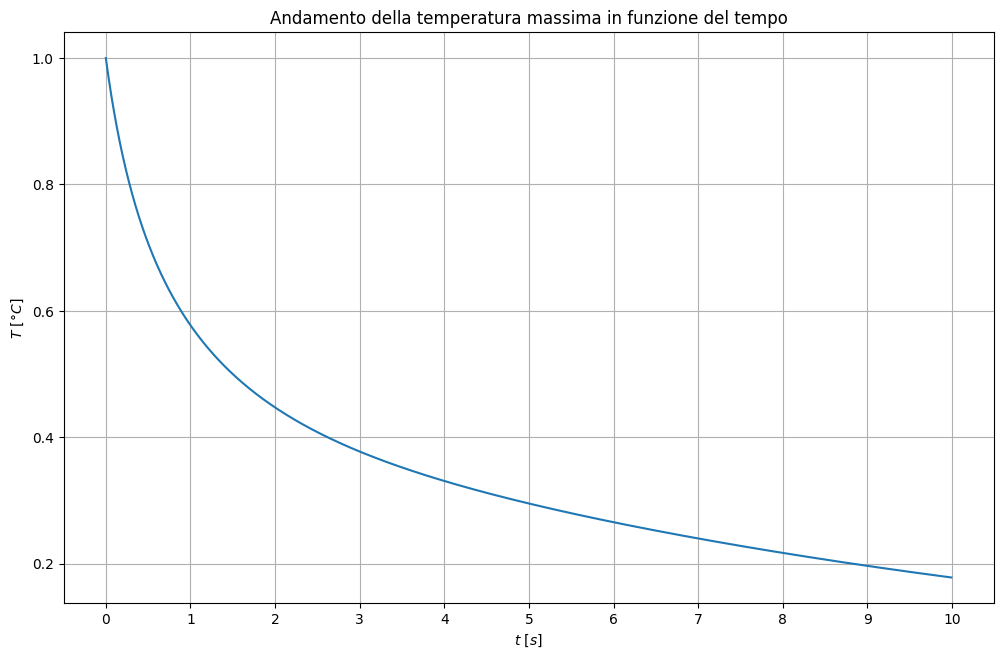

In [108]:
ts_max = []
for tst in Ts1:
    ts_max.append(max(tst))

time_ticks = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
index_ticks = [t / dt for t in time_ticks]


plt.plot(ts_max)
plt.grid()
plt.xticks(index_ticks, time_ticks)
plt.xlabel(r"$t\ [s]$")
plt.ylabel(r"$T\ [°C]$")
plt.title("Andamento della temperatura massima in funzione del tempo")
plt.show()

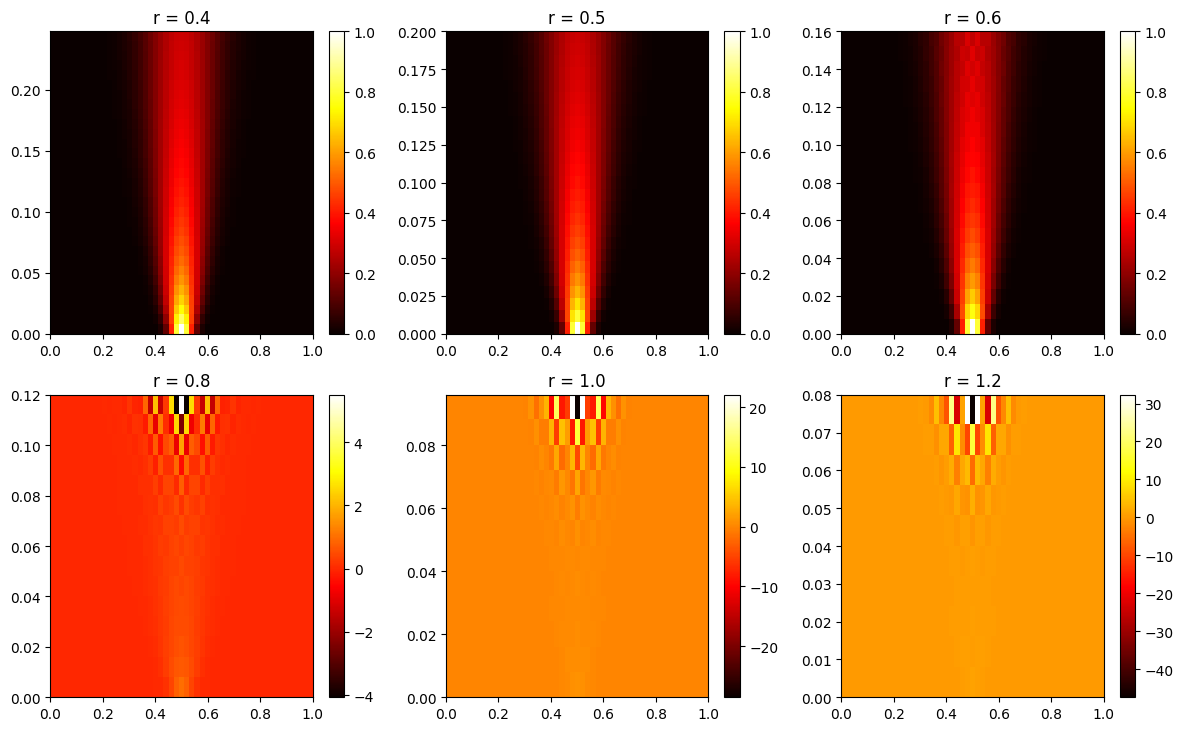

In [170]:
def ftcs2(T0: float, Tl: float, Tr: float, x: list[float], t: float, r: float, L: float, dx: float, alpha: float) -> list[float]:
    sigma = 0.03 * L
    dt = dx**2 * r / alpha
    steps = t / dt
    Ts = np.ones((int(steps), len(x)))
    Ts[0] = T0 * np.exp(-(x - L/2)**2 / (2 * sigma**2))
    
    for i in range(int(steps)-1):
        for j in range(1, len(xs)-1):
            Ts[i+1][j] = Ts[i][j] + r * (Ts[i][j+1] - 2*Ts[i][j] + Ts[i][j-1])
        Ts[i+1][0], Ts[i+1][-1] = Tl, Tr
    return Ts

fig, axes = plt.subplots(2, 3)

r_values = [0.4, 0.5, 0.6, 0.8, 1.0, 1.2]
axes_flat = axes.flatten()

for i, r_val in enumerate(r_values):
    data = ftcs2(T0=T0, Tl=0, Tr=0, x=xs, t=0.5, r=r_val, L=L, dx=dx, alpha=alpha)
    ext = [0, L, 0, len(data)*dt]
    im = axes_flat[i].imshow(data, extent=ext, aspect="auto", origin="lower", cmap="hot")
    axes_flat[i].set_title(f"r = {r_val}")
    fig.colorbar(im, ax=axes_flat[i])

plt.tight_layout()
plt.show()

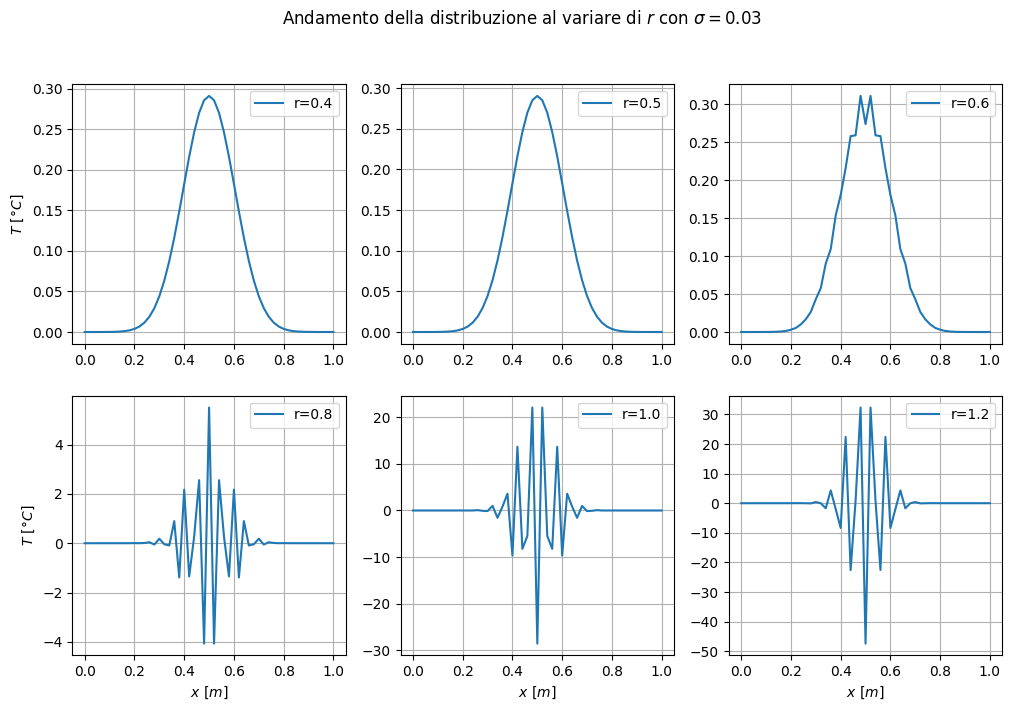

In [110]:
fig, axes = plt.subplots(2, 3)

axes[0,0].plot(xs, ftcs2(T0=T0, Tl=0, Tr=0, x=xs, t=0.5, r=0.4, L=L, dx=dx, alpha=alpha)[-1, :], label="r=0.4")
axes[0,0].grid(True)
axes[0,0].set_ylabel(r"$T\ [°C]$")
axes[0,0].legend()

axes[0,1].plot(xs, ftcs2(T0=T0, Tl=0, Tr=0, x=xs, t=0.5, r=0.5, L=L, dx=dx, alpha=alpha)[-1, :], label="r=0.5")
axes[0,1].grid(True)
axes[0,1].legend()

axes[0,2].plot(xs, ftcs2(T0=T0, Tl=0, Tr=0, x=xs, t=0.5, r=0.6, L=L, dx=dx, alpha=alpha)[-1, :], label="r=0.6")
axes[0,2].grid(True)
axes[0,2].legend()

axes[1,0].plot(xs, ftcs2(T0=T0, Tl=0, Tr=0, x=xs, t=0.5, r=0.8, L=L, dx=dx, alpha=alpha)[-1, :], label="r=0.8")
axes[1,0].grid(True)
axes[1,0].set_xlabel(r"$x\ [m]$")
axes[1,0].set_ylabel(r"$T\ [°C]$")
axes[1,0].legend()

axes[1,1].plot(xs, ftcs2(T0=T0, Tl=0, Tr=0, x=xs, t=0.5, r=1.0, L=L, dx=dx, alpha=alpha)[-1, :], label="r=1.0")
axes[1,1].grid(True)
axes[1,1].set_xlabel(r"$x\ [m]$")
axes[1,1].legend()

axes[1,2].plot(xs, ftcs2(T0=T0, Tl=0, Tr=0, x=xs, t=0.5, r=1.2, L=L, dx=dx, alpha=alpha)[-1, :], label="r=1.2")
axes[1,2].grid(True)
axes[1,2].set_xlabel(r"$x\ [m]$")
axes[1,2].legend()

plt.suptitle(r"Andamento della distribuzione al variare di $r$ con $\sigma=0.03$")
plt.show()

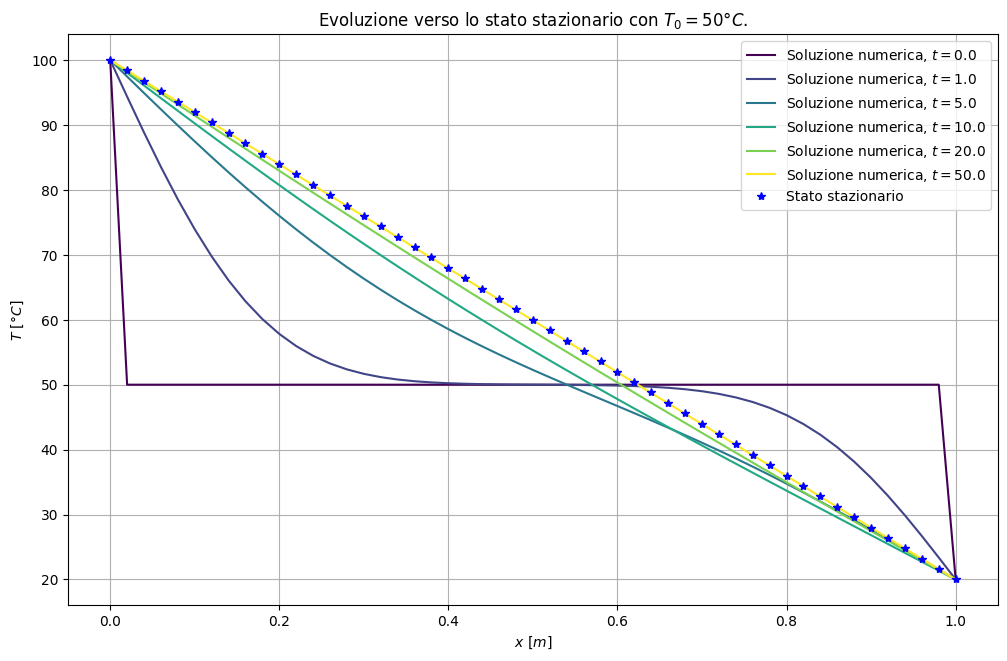

In [167]:
def ftcs3(T0: float, Tl: float, Tr: float, x: list[float], t: float, dt: float, L: float, alpha: float, dx: float) -> list[float]:
    r = alpha * dt / (dx**2)
    steps = t / dt
    Ts = np.zeros((int(steps), len(x)))
    Ts[0,:] = T0
    Ts[:, 0], Ts[:, -1] = Tl, Tr
    
    for i in range(int(steps)-1):
        for j in range(1, len(xs)-1):
            Ts[i+1][j] = Ts[i][j] + r * (Ts[i][j+1] - 2*Ts[i][j] + Ts[i][j-1])
    return Ts

Ts3 = ftcs3(T0=50, Tl=100, Tr=20, x=xs, t=50, dt=dt, L=L, alpha=alpha, dx=dx)
times = [0.0, 1.0, 5.0, 10.0, 20.0, 50.0]
cmap = plt.cm.viridis

for idx, t in enumerate(times):
    riga = int(t/dt)
    colore = cmap(idx / (len(times) - 1))
    if riga == 0:
        plt.plot(xs, Ts3[riga, :], label=rf"Soluzione numerica, $t={t}$", color=colore)
    else:
        plt.plot(xs, Ts3[riga-1, :], label=rf"Soluzione numerica, $t={t}$", color=colore)

plt.plot(xs, 100-80*xs, "*", label="Stato stazionario", color="blue", lw=0.8)
plt.xlabel(r"$x\ [m]$")
plt.ylabel(r"$T\ [°C]$")
plt.legend()
plt.grid()
plt.title(r"Evoluzione verso lo stato stazionario con $T_0=50°C$.")
plt.show()

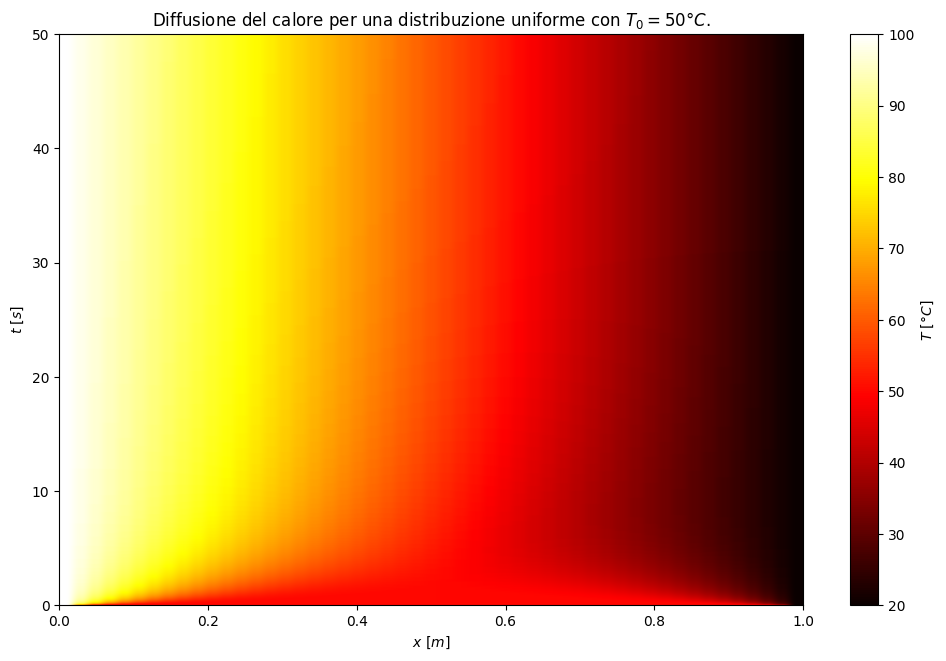

In [169]:
extent3 = [0, L, 0, len(Ts3)*dt]
plt.imshow(Ts3, extent=extent3, aspect="auto", origin="lower", cmap="hot")
cbar = plt.colorbar()
cbar.set_label(r"$T\ [°C]$")
plt.xlabel(r"$x\ [m]$")
plt.ylabel(r"$t\ [s]$")
plt.title(r"Diffusione del calore per una distribuzione uniforme con $T_0=50°C$.")
plt.show()